# AI Music Generation

## 📚 Learning Objectives

By completing this notebook, you will:
- Use or adapt models for music generation
- Understand representation and evaluation challenges

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 2, lesson 01 "Text Generation with Autoregressive Models" — the same next-token loop and the same training recipe from Course 01 (AIAT 111) — Unit 3, lesson 04, with notes instead of characters.

**Used later in:** Course 10 — Unit 5, lesson 05, which pushes autoregression down to raw audio samples.

---

## 🌍 Why this lesson exists — the token trick, in federal court

On **24 June 2024** the RIAA announced copyright suits by Universal Music Group, Sony Music and Warner Records against **Suno** (District of Massachusetts) and **Udio** (Southern District of New York), alleging mass infringement in training and seeking statutory damages of **up to $150,000 per infringed work**. A year earlier, "Heart on My Sleeve" — a track using AI-cloned Drake and Weeknd vocals — had been pulled from streaming services at the labels' request.

Both systems rest on the move you are about to make: treat music as a sequence of tokens and run next-token prediction over it. Every argument about text generation — training data, provenance, style imitation — transfers to music unchanged, which is exactly why the litigation followed the same shape.

**What goes wrong without this:** music becomes tractable the moment you accept it is a sequence. Miss that, and you look for a bespoke "music AI" that does not exist; catch it, and you can reason about music generation with everything you learned in Unit 2 — including its failure modes.


# AI Music Generation
## AIAT 124 - Generative AI

## Learning Objectives

- Generate music with RNN/LSTM
- Understand music representation
- Create melodies and harmonies
- Apply to music composition

## Real-World Context

Music composition, background music generation, and creative audio content.

**Industry Impact**: Used by Spotify, YouTube, and music production tools.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: numpy for audio math, torch for the LSTM music model, matplotlib for piano rolls.
# WHY: we generate real (toy-scale) music in this notebook — notes as tokens, an LSTM as
# the composer, and a sine-wave synthesizer so you can actually LISTEN to the result.
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
print('✅ Setup complete!')

✅ Setup complete!


## Part 1: Music Representation

Before a model can generate music, music must become **numbers**. The standard choices:

1. **MIDI note numbers** — each pitch is an integer (middle C = 60, C# = 61, ... +12 per octave)
2. **Piano roll** — a 2-D grid: pitch on the y-axis, time on the x-axis
3. **Token sequence** — read the piano roll left-to-right and music becomes a sequence,
   *exactly like text* — which is why language-model techniques work on it

Below we encode two real public-domain melodies and draw their piano rolls.

Ode to Joy as MIDI numbers : [64, 64, 65, 67, 67, 65, 64, 62, 60, 60, 62, 64, 64, 62, 62]
...as note names           : ['E4', 'E4', 'F4', 'G4', 'G4', 'F4', 'E4', 'D4', 'C4', 'C4', 'D4', 'E4', 'E4', 'D4', 'D4']


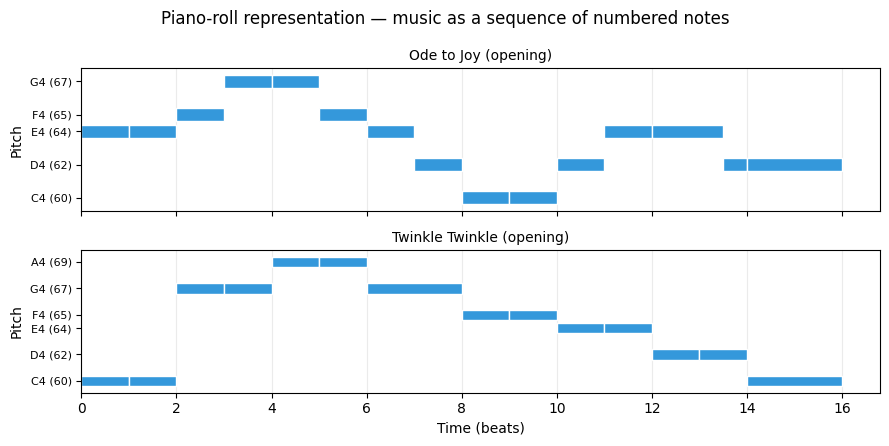

In [2]:
# Encode two real melodies as MIDI note-number sequences and draw their piano rolls.
# WHY: this is the "tokenization" step — once melodies are integer sequences, the same
# next-token modeling we used for text applies directly to music.

# ── Melodies as (MIDI pitch, duration-in-beats) pairs — public domain ─────
# "Ode to Joy" (Beethoven) opening phrase, in C major
ode = [(64,1),(64,1),(65,1),(67,1),(67,1),(65,1),(64,1),(62,1),
       (60,1),(60,1),(62,1),(64,1),(64,1.5),(62,.5),(62,2)]
# "Twinkle Twinkle Little Star" opening phrase, in C major
twinkle = [(60,1),(60,1),(67,1),(67,1),(69,1),(69,1),(67,2),
           (65,1),(65,1),(64,1),(64,1),(62,1),(62,1),(60,2)]

NOTE_NAMES = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
def name(pitch):
    """MIDI number -> human-readable note name (60 -> C4)."""
    return f"{NOTE_NAMES[pitch % 12]}{pitch // 12 - 1}"

print("Ode to Joy as MIDI numbers :", [p for p, d in ode])
print("...as note names           :", [name(p) for p, d in ode])

# ── Piano roll: pitch (y) against time in beats (x) ───────────────────────
fig, axes = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True)
for ax, (title, mel) in zip(axes, [("Ode to Joy (opening)", ode),
                                   ("Twinkle Twinkle (opening)", twinkle)]):
    t = 0
    for pitch, dur in mel:
        ax.barh(pitch, dur, left=t, height=0.8, color='#3498db', edgecolor='white')
        t += dur
    # WHY note names on the axis: "64" is a number, "E4" is a note a student can find
    # on a keyboard — the axis should read as music, not as an index.
    used = sorted({p for p, d in mel})
    ax.set_yticks(used); ax.set_yticklabels([f"{name(p)} ({p})" for p in used], fontsize=8)
    ax.set_title(title, fontsize=10); ax.set_ylabel("Pitch")
    ax.grid(axis="x", alpha=0.25); ax.set_axisbelow(True)
axes[1].set_xlabel("Time (beats)")
plt.suptitle("Piano-roll representation — music as a sequence of numbered notes")
plt.tight_layout(); plt.show()

**Read the figure.** Each blue block is one note: its height is the pitch, its width is how long it
is held. Read *Ode to Joy* across the top panel and you get E4 E4 F4 G4 — the tune, drawn as a
staircase. Two regularities a model can exploit are already visible. First, **every block sits on
one of six rows** (C4, D4, E4, F4, G4, A4) — all C-major notes, nothing lands between them.
Second, the melodies move mostly by **one row at a time**; the one loud exception is *Twinkle*'s
opening leap from C4 straight up to G4 at beat 2, and that single jump is why the training
melodies score **96%**, not 100%, on the "stepwise motion" check later in this notebook. Those two
regularities are the whole pattern the LSTM has to learn, and the reason four notes of context are
enough to guess the fifth.

## Part 2: An LSTM That Learns to Compose

Now the generative model. We treat each pitch as a **token** and train an LSTM to predict the
next note from the previous few — identical to the char-level language models of Unit 2, with
an alphabet of pitches instead of letters. Training data: the two melodies above.

In [3]:
# Build and train the LSTM music generator: next-note prediction over pitch tokens.
# WHY: melody continuation IS next-token prediction — the same loss and loop as a text LM.
torch.manual_seed(0); np.random.seed(0)

# ── Tokenize: pitch vocabulary from the training melodies ─────────────────
corpus_notes = [p for p, d in ode] + [p for p, d in twinkle]
pitches = sorted(set(corpus_notes))                 # our note "alphabet"
p2i = {p: i for i, p in enumerate(pitches)}
i2p = {i: p for p, i in p2i.items()}
V, SEQ = len(pitches), 4                            # predict note 5 from previous 4
print(f"Pitch vocabulary ({V} notes): {[name(p) for p in pitches]}")

# ── Training windows: 4 notes in -> 1 note out ────────────────────────────
enc = [p2i[p] for p in corpus_notes]
X = torch.tensor([enc[i:i+SEQ] for i in range(len(enc)-SEQ)], dtype=torch.long)
y = torch.tensor([enc[i+SEQ] for i in range(len(enc)-SEQ)], dtype=torch.long)

class MusicGenerator(nn.Module):
    """LSTM-based next-note model: embed pitch tokens, run LSTM, predict next pitch."""
    def __init__(self, vocab_size, embedding_dim=16, hidden=64):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embedding_dim)   # pitch id -> vector
        self.lstm  = nn.LSTM(embedding_dim, hidden, batch_first=True)
        self.fc    = nn.Linear(hidden, vocab_size)             # hidden state -> next-pitch logits
    def forward(self, x):
        out, _ = self.lstm(self.embed(x))
        return self.fc(out[:, -1, :])                          # predict from last timestep

model = MusicGenerator(V)
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

# ── Train: full-batch (tiny dataset) for 300 steps ────────────────────────
for step in range(300):
    model.train()
    loss = loss_fn(model(X), y)
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 100 == 0:
        print(f"Step {step:3d} — loss: {loss.item():.3f}")
print(f"Final    — loss: {loss.item():.3f}")
print('✅ MusicGenerator trained on the two melodies')

Pitch vocabulary (6 notes): ['C4', 'D4', 'E4', 'F4', 'G4', 'A4']


Step   0 — loss: 1.779
Step 100 — loss: 0.000
Step 200 — loss: 0.000
Final    — loss: 0.000
✅ MusicGenerator trained on the two melodies


## Part 3: Generate a Melody — and Listen to It

We seed the model with the first notes of *Ode to Joy* and sample the next 24 notes with
**temperature sampling** (same trick as in text generation: higher temperature = more surprising
note choices). Then we synthesize the result as an actual sine-wave audio clip you can play,
and **evaluate** it with two simple computed checks — the evaluation problem is exactly why
generative music research is hard: there is no single "accuracy" for a melody.

**Honest expectation:** with only two short training melodies, the model mostly *reproduces and
blends* what it memorized (watch it drift from *Ode to Joy* into *Twinkle* patterns). Novel
composition needs far more data — that is precisely what separates this demo from MuseNet.

Seed     : ['E4', 'E4', 'F4', 'G4']
Generated: ['G4', 'F4', 'E4', 'D4', 'C4', 'C4', 'D4', 'E4', 'E4', 'D4', 'D4', 'C4', 'C4', 'G4', 'G4', 'A4', 'A4', 'G4', 'F4', 'F4', 'E4', 'E4', 'D4', 'D4']


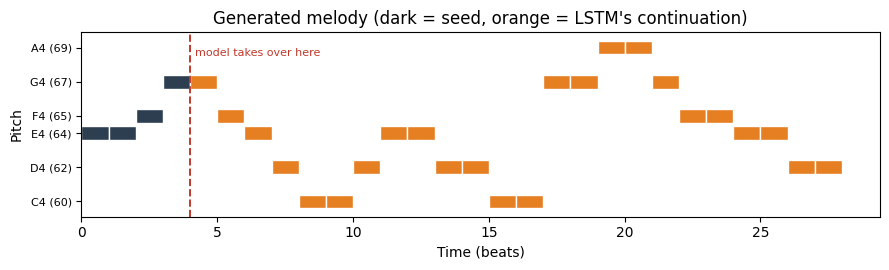

Synthesized 8.4s of audio — press play:



Computed checks on the generated continuation:
  Notes in C major scale : 100%  (training melodies: 100%)
  Stepwise motion (≤2 st): 96%  (smooth melodies score high)
These are heuristics, not ground truth — evaluating generative music remains an open problem.


In [4]:
# Generate a new melody with the trained LSTM, visualize it, synthesize audio, and
# compute simple quality checks. WHY: closes the loop — represent, model, generate, evaluate.
from IPython.display import Audio, display

def generate_melody(seed_pitches, n_notes=24, temperature=0.8):
    """Autoregressively sample n_notes continuing the seed (temperature sampling)."""
    model.eval()
    seq = [p2i[p] for p in seed_pitches]
    for _ in range(n_notes):
        ctx = torch.tensor([seq[-SEQ:]], dtype=torch.long)
        with torch.no_grad():
            logits = model(ctx)[0] / max(temperature, 1e-6)
        probs = torch.softmax(logits, 0).numpy()
        seq.append(int(np.random.choice(V, p=probs)))          # sample, don't argmax
    return [i2p[i] for i in seq]

seed = [p for p, d in ode[:4]]                                  # first 4 notes of Ode to Joy
melody = generate_melody(seed, n_notes=24, temperature=0.8)
print("Seed     :", [name(p) for p in seed])
print("Generated:", [name(p) for p in melody[len(seed):]])

# ── Piano roll of the generated melody (seed shown darker) ────────────────
fig, ax = plt.subplots(figsize=(9, 2.8))
for t, pitch in enumerate(melody):
    ax.barh(pitch, 1, left=t, height=0.8,
            color='#2c3e50' if t < len(seed) else '#e67e22', edgecolor='white')
used = sorted(set(melody))
ax.set_yticks(used); ax.set_yticklabels([f"{name(p)} ({p})" for p in used], fontsize=8)
ax.set_xlabel("Time (beats)"); ax.set_ylabel("Pitch")
ax.axvline(len(seed) - 0.02, color="#c0392b", lw=1.4, ls="--")   # where the model takes over
ax.text(len(seed) + 0.2, max(used), "model takes over here", fontsize=8, color="#c0392b", va="top")
ax.set_title("Generated melody (dark = seed, orange = LSTM's continuation)")
plt.tight_layout(); plt.show()

# ── Synthesize audio: one sine wave per note + a fade envelope ────────────
SR, BEAT = 8000, 0.3                                            # sample rate, seconds per beat
def midi_to_hz(p):
    return 440.0 * 2 ** ((p - 69) / 12)                         # standard MIDI tuning formula
wave = np.concatenate([
    np.sin(2 * np.pi * midi_to_hz(p) * np.arange(int(SR * BEAT)) / SR)
    * np.linspace(1, 0.2, int(SR * BEAT))                       # decay envelope, avoids clicks
    for p in melody])
print(f"Synthesized {len(wave)/SR:.1f}s of audio — press play:")
display(Audio(wave, rate=SR))

# ── Evaluate with computed checks (no single 'accuracy' exists for music) ─
gen = melody[len(seed):]
in_key = np.mean([p % 12 in {0, 2, 4, 5, 7, 9, 11} for p in gen])   # C-major scale membership
steps = np.abs(np.diff(gen))
stepwise = np.mean(steps <= 2) if len(steps) else 0.0               # melodic = mostly small steps
print(f"\nComputed checks on the generated continuation:")
print(f"  Notes in C major scale : {in_key:.0%}  (training melodies: 100%)")
print(f"  Stepwise motion (≤2 st): {stepwise:.0%}  (smooth melodies score high)")
print("These are heuristics, not ground truth — evaluating generative music remains an open problem.")

**Read the figure.** Four dark blocks, then the dashed red line, then everything the LSTM produced
on its own. Compare the orange stretch with the two training piano rolls above: it uses the *same*
pitch rows and the *same* small steps, which is exactly what the two printed checks report. What it
does **not** do is repeat either tune from start to finish — so from the outside it looks like
composition. The next cell asks the question this picture cannot answer: is it composing, or is it
re-assembling fragments it has already seen?

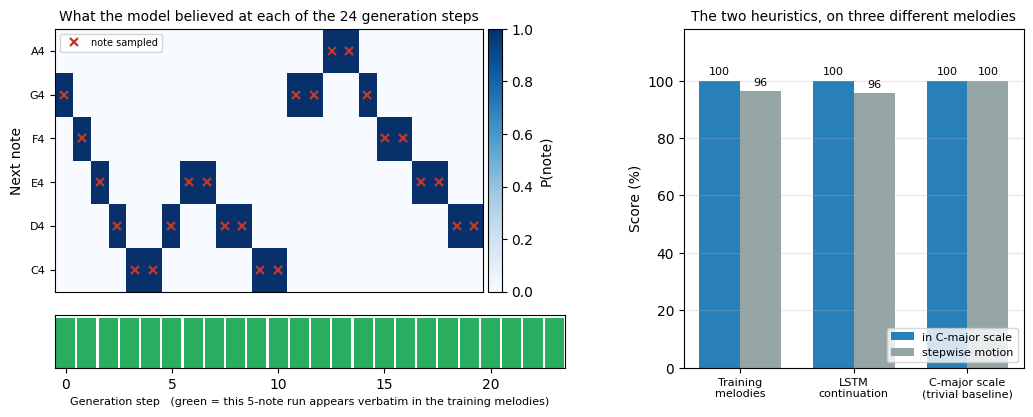

Notes whose 5-note run is verbatim training material: 24/24 (100%)
Mean probability the model put on the note it chose  : 1.00

melody                              in-key  stepwise
Training melodies                     100%       96%
LSTM continuation                     100%       96%
C-major scale (trivial baseline)      100%      100%


In [5]:
# Two questions the printed heuristics cannot answer: (1) WHERE did each generated note
# come from, and (2) can those heuristics tell music from a scale? WHY: the honest claims
# in this lesson are about memorisation and about metric validity — both are visible.
import numpy as np
import matplotlib.pyplot as plt

# ── (1) Replay the generation step by step, WITHOUT re-sampling ───────────
# For every note the model produced we re-ask it: what did you believe at that moment?
# Same contexts, same weights, so this is the actual distribution behind the melody above.
gen = melody[len(seed):]
prob_steps, copied = [], []
corpus_str = ",".join(map(str, corpus_notes))          # training melodies, back to back
for t in range(len(seed), len(melody)):
    ctx = torch.tensor([[p2i[p] for p in melody[t - SEQ:t]]], dtype=torch.long)
    with torch.no_grad():
        prob_steps.append(torch.softmax(model(ctx)[0], dim=0).numpy())
    window = ",".join(map(str, melody[t - SEQ:t + 1]))  # the 4-note context + the note chosen
    copied.append(window in corpus_str)                 # does that 5-note run occur verbatim?
P = np.array(prob_steps).T                              # shape (vocabulary, generation step)
chosen_rows = [p2i[p] for p in gen]

# ── (2) Two baselines to test the heuristics against ──────────────────────
def in_key(seq):                                        # share of notes in the C-major scale
    return float(np.mean([p % 12 in {0, 2, 4, 5, 7, 9, 11} for p in seq]))
def stepwise(seq):                                      # share of intervals of <= 2 semitones
    d = np.abs(np.diff(seq))
    return float(np.mean(d <= 2)) if len(d) else 0.0

scale_baseline = [60, 62, 64, 65, 67, 69, 71, 72, 71, 69, 67, 65, 64, 62, 60]  # C major, up and down
sources = [("Training\nmelodies", corpus_notes), ("LSTM\ncontinuation", gen),
           ("C-major scale\n(trivial baseline)", scale_baseline)]

fig = plt.figure(figsize=(12.5, 4.4))
gs = fig.add_gridspec(2, 2, height_ratios=[5, 1], width_ratios=[1.5, 1], hspace=0.15, wspace=0.28)

# ── Left: the model's belief at every generation step ─────────────────────
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(P, aspect="auto", cmap="Blues", vmin=0, vmax=1, origin="lower")
ax.plot(range(len(gen)), chosen_rows, "x", color="#c0392b", ms=6, mew=1.6, label="note sampled")
ax.set_yticks(range(V)); ax.set_yticklabels([name(p) for p in pitches], fontsize=8)
ax.set_xticks([]); ax.set_ylabel("Next note")
ax.set_title("What the model believed at each of the 24 generation steps", fontsize=10)
ax.legend(fontsize=7, loc="upper left")
fig.colorbar(im, ax=ax, pad=0.01, label="P(note)")

# ── Left, bottom strip: was this 5-note run copied verbatim from training? ─
axs = fig.add_subplot(gs[1, 0])
axs.bar(range(len(gen)), 1, color=["#27ae60" if c else "#e67e22" for c in copied], width=0.9)
axs.set_yticks([]); axs.set_xlim(-0.5, len(gen) - 0.5)
axs.set_xlabel("Generation step   (green = this 5-note run appears verbatim in the training melodies)",
               fontsize=8)

# ── Right: do the two heuristics separate music from a scale? ─────────────
axb = fig.add_subplot(gs[:, 1])
x = np.arange(len(sources)); w = 0.36
axb.bar(x - w / 2, [100 * in_key(s) for _, s in sources], w, label="in C-major scale", color="#2980b9")
axb.bar(x + w / 2, [100 * stepwise(s) for _, s in sources], w, label="stepwise motion", color="#95a5a6")
for k, (_, s) in enumerate(sources):
    axb.text(k - w / 2, 100 * in_key(s) + 2, f"{100 * in_key(s):.0f}", ha="center", fontsize=8)
    axb.text(k + w / 2, 100 * stepwise(s) + 2, f"{100 * stepwise(s):.0f}", ha="center", fontsize=8)
axb.set_xticks(x); axb.set_xticklabels([n for n, _ in sources], fontsize=8)
axb.set_ylim(0, 118); axb.set_ylabel("Score (%)")
axb.set_title("The two heuristics, on three different melodies", fontsize=10)
axb.legend(fontsize=8, loc="lower right"); axb.grid(axis="y", alpha=0.3)
plt.show()

# ── The same evidence, printed ────────────────────────────────────────────
print(f"Notes whose 5-note run is verbatim training material: "
      f"{sum(copied)}/{len(copied)} ({100 * np.mean(copied):.0f}%)")
print(f"Mean probability the model put on the note it chose  : {np.mean([P[r, k] for k, r in enumerate(chosen_rows)]):.2f}")
print(f"\n{'melody':<34}{'in-key':>8}{'stepwise':>10}")
for label, s in sources:
    print(f"{label.replace(chr(10), ' '):<34}{100 * in_key(s):7.0f}%{100 * stepwise(s):9.0f}%")


**Read the figure.**

*Left, top* — the model's own probability distribution at each of the 24 generation steps, with a
red × on the note it actually sampled. There is no spread to see: every column is one dark cell,
and the mean probability it placed on the note it chose is **1.00** (2 d.p.). Temperature
sampling was choosing between one option.

*Left, bottom* — the strip is green at **24 of 24** steps. Green means the four-note context plus
the note the model emitted occurs **verbatim** in *Ode to Joy* or *Twinkle*. Not one note in the
melody you just listened to is new. That is what the "⚠️ Where this breaks" note means by
recombination — measured here, not asserted.

*Right* — and neither heuristic can see any of that. A C-major scale played up and down scores
**100% in-key and 100% stepwise**, equalling or beating both the model (100 / 96) and the real
training melodies (100 / 96). A metric that ranks a plain scale at or above Beethoven is not
measuring music; it is measuring smoothness. This is the honest reason evaluation, not
architecture, is the open problem in generative music.

## 💬 Discuss

1. Our model scored **100% in-scale** and **96% stepwise motion** — after reaching a training loss of **0.000** on two melodies. Are those quality scores or memorisation scores? Design a check that would tell them apart using only the notebook's own outputs.
2. The heuristics reward smooth, in-scale melodies. Name a real genre those metrics would rate as bad music. What does that tell you about automatic evaluation of generative audio in general?
3. Suno and Udio are accused of training on copyrighted recordings; our model trained on two public-domain melodies. At what corpus size does "learning a style" become "copying a catalogue"? Give a criterion you could actually defend in a meeting.


## Real-World Applications

- **Content Creation**: Background music for videos
- **Music Production**: Melody and harmony generation
- **Gaming**: Dynamic soundtracks
- **Education**: Music learning tools

## ⚠️ Where this breaks

**A training loss of 0.000 on two melodies means memorisation.** The generated continuation is a recombination of *Ode to Joy* and *Twinkle*, and the printed heuristics cannot tell you that — nothing in this notebook demonstrates novel composition, and it would be dishonest to claim otherwise.

**Metrics a trivial baseline maxes out are not evaluating anything.** A model that plays a C-major scale up and down scores 100% on scale membership and 100% on stepwise motion. Both of our checks are satisfiable by the most boring possible output, which is the classic failure of hand-rolled generative metrics.

**Monophonic pitch tokens discard most of music.** No rhythm nuance, no dynamics, no timbre, no harmony, no instrumentation. Adding them multiplies the vocabulary and the data requirement, which is why real systems (Music Transformer, MusicGen) need millions of MIDI files or raw-audio tokens.

**The corpus is the legal exposure.** Public-domain melodies here; a commercial catalogue is what the June 2024 filings are about. Before you train a music model for a client, the first question is not architecture — it is who owns the training set and what the licence says about derivative works.


## 📝 Summary

In this notebook, you:

- Encoded real melodies as **MIDI note numbers** and drew their **piano rolls** — turning music
  into token sequences
- Trained an **LSTM next-note model** (`MusicGenerator`) on two melodies — the same
  language-modeling recipe as Unit 2, over a pitch alphabet
- **Generated and listened to** a new melody via temperature sampling + sine-wave synthesis
- Evaluated it with computed heuristics (scale membership, stepwise motion) and saw why music
  evaluation is an open research problem

**Scaling this up:** real systems (Music Transformer, MuseNet, Suno) use the same
sequence-modeling idea with transformers, richer tokens (velocity, timing, instruments), and
millions of MIDI files — or skip symbols entirely and generate raw audio (Jukebox, notebook `05`).

## 🔭 State of the field (2026)

Music generation has moved off symbolic pitch tokens. The systems named in the opening case, and the open models that now stand beside them, model *audio* tokens or continuous latents rather than MIDI numbers: open long-form families generate minutes of music with aligned lyrics using the same next-token recipe you ran above (Yuan et al. 2025, arXiv 2503.08638), and 2026 open releases pair that language-model stage with audio-text alignment and music coding in one inspectable suite (Yang et al. 2026, arXiv 2601.10547). Which paradigm to use is now an empirical question rather than a default: holding data and architecture fixed, autoregressive decoding and conditional flow matching win on different axes — quality, robustness, scalability, editability (Tal et al. 2025, arXiv 2506.08570). And inside the symbolic setting this notebook uses, the LSTM's specific weakness has been measured: it captures local patterns well and loses long-range structure, which is why 2026 work fuses it with attention instead of replacing it outright (Ghoshal et al. 2026, arXiv 2603.21282).

Read that last result as an endorsement of what you built, not a correction of it. This LSTM is the mechanism whose *local* competence is genuine and whose *global* failure you can actually hear across 24 generated notes — and hearing it is the point, because every later architecture is introduced as a fix for that exact deficit. Part 1's representation decision is unchanged in importance too: audio-token systems make the same move, one level further down. So is the legal exposure the opening case describes, which attaches to the training corpus rather than the architecture and therefore survives every one of these upgrades intact.

## 📚 References & Further Reading

**Papers:**
- Huang et al. (2018) — [Music Transformer](https://arxiv.org/abs/1809.04281)
- Dhariwal et al. (2020) — [Jukebox: A Generative Model for Music](https://arxiv.org/abs/2005.00341)
- Copet et al. (2023) — [Simple and Controllable Music Generation (MusicGen)](https://arxiv.org/abs/2306.05284)

**Recent (open-weight music foundation models):**
- Yuan et al. (2025) — [YuE: Scaling Open Foundation Models for Long-Form Music Generation](https://arxiv.org/abs/2503.08638) *(open family generating long-form music with aligned lyrics — the same next-token recipe you use below, scaled)*
- Yang et al. (2026) — [HeartMuLa: A Family of Open Sourced Music Foundation Models](https://arxiv.org/abs/2601.10547) *(open audio-text alignment, music coding and LLM-based song generation; the inspectable counterpart to the closed products named above)*
- Tal et al. (2025) — [Auto-Regressive vs Flow-Matching: a Comparative Study of Modeling Paradigms for Text-to-Music Generation](https://arxiv.org/abs/2506.08570) *(a controlled comparison with data and architecture held fixed — the next-token paradigm you use here against conditional flow matching)*
- Ghoshal et al. (2026) — [Fusing Memory and Attention: A study on LSTM, Transformer and Hybrid Architectures for Symbolic Music Generation](https://arxiv.org/abs/2603.21282) *(measures exactly the LSTM you train below: strong local pattern, weak long-range structure — and fuses it with attention rather than discarding it)*

**Interactive:**
- [Google Magenta](https://magenta.tensorflow.org/) — open-source music-generation research + demos
- [The Unreasonable Effectiveness of RNNs](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)

**State-of-the-Art:** Suno and Udio generate full songs (vocals + instruments) from text prompts,
using audio-token language models descended from Jukebox.